# Computer Vision, Assignment 2: Calibration and DLT

In this assignment you will study camera calibration, the projective ambiguity, and the DLT method. 

You will solve the resection and triangulation problems using DLT and compute inner parameters using RQ factorization.
In addition you will try out SIFT for feature detection/matching.

Please see Canvas for detailed instructions on what is expected for a passing/higher grade. All computer exercises not marked **OPTIONAL** are "mandatory" in the sense described on Canvas.

### Submission Requirements:
Your final lab submission should include:
1. Your edited **notebook file** (`.ipynb`).
2. An **HTML printout** of the executed notebook with all outputs visible: File → Save and export Notebook As → HTML
3. A **pdf report** containing answers to the theoretical exercises (see separate document).


In [1]:
import cv2
import matplotlib.image as mpimg
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.io
from supplied import pflat, plot_camera

# Calibrated vs. Uncalibrated Reconstruction

#### *Theoretical exercise 1* (see pdf)

## Computer Exercise 1
Figure 1 shows an image of a scene and a reconstruction using uncalibrated cameras. The file `compEx1data.mat` contains 
the 3D points of the reconstruction `X`, the camera matrices `P`, the image points `x` and the filenames `imfiles` of the images.
Here `X` is a $4 \times 9471$ matrix containing the homogeneous coordinates for all 3D points, `x{i}` is a $3 \times 9471$ matrix containing the homogeneous coordinates of the image points seen in image $i$ (`NaN` means that the point has not been detected in this image). `P{i}` contains the camera matrix of image $i$ and `imfiles{i}` contains the name of that image.

<figure align="center">
    <img alt="left" src="figs/DSC_0025.JPG" width="250px">
&nbsp; &nbsp; &nbsp; &nbsp;
    <img alt="right" src="figs/projective_rec.png" width="150px">
    <figcaption>Figure 1: Left: An image of the scene. Right: A projective (uncalibrated) reconstruction.</figcaption>
</figure>

### Task 1.1
Plot the 3D points of the reconstruction. Use the supplied function `plot_camera` to plot the cameras in the same figure.

**Do the physical properties (such as the relative heights of each of the two walls, the angle in the corner, and the relation between the width, height, and depth dimensions) look realistic in the reconstruction?**

Don't forget to use `ax.set_aspect('equal')` when plotting -- otherwise you may get additional distortion. The reconstruction should look like the one shown in Figure 1.

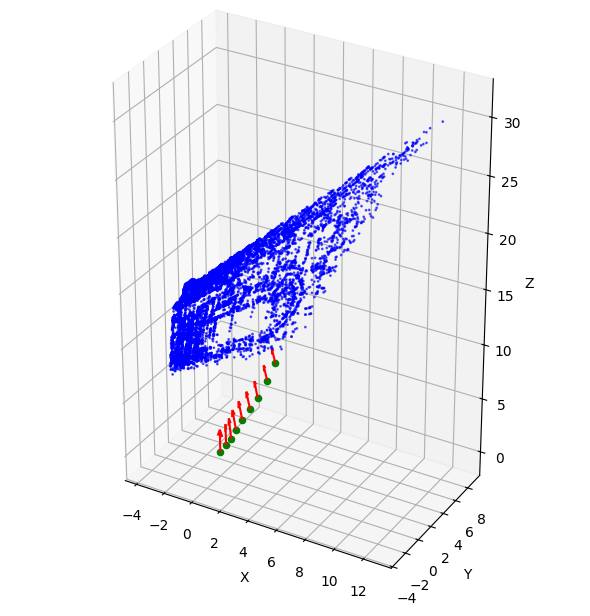

In [2]:

# ------ Your code here ------ 
# 1) Load data
data = scipy.io.loadmat('data/compEx1data.mat', squeeze_me=True, struct_as_record=False)

X = np.asarray(data['X'])    # 4 x N homogeneous 3D points
P_raw = data['P']   # cell array of 3x4 projection matrices

# Convert MATLAB cell array to a Python list of 3x4 numpy arrays
def cell_to_list(a):
    a = np.atleast_1d(a).squeeze()
    if isinstance(a, np.ndarray) and a.dtype == object:
        return [np.array(a[i]) for i in range(a.size)]
    return [np.array(a)]

P_list = cell_to_list(P_raw)

# 2) Convert 3D points to Euclidean and plot
X_e = pflat(X)[:3, :]     # 3 x N Euclidean coordinates

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

# Point cloud
ax.scatter(X_e[0], X_e[1], X_e[2], s=1, c='b', alpha=0.6)

# 3) Plot cameras
# Choose a camera-axis scale proportional to the scene size
extent = np.array([np.ptp(X_e[0]), np.ptp(X_e[1]), np.ptp(X_e[2])], dtype=float)
diag = np.linalg.norm(extent) if np.all(np.isfinite(extent)) else 1.0
cam_scale = 0.07 * diag if diag > 0 else 1.0

for Pi in P_list:
    plot_camera(Pi, cam_scale, ax=ax)

# 4) Make the axes roughly “equal” to avoid extra visual distortion
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
try:
    # Works in newer Matplotlib versions for 3D
    ax.set_aspect('equal')
except Exception:
    pass

# Robust equal-aspect visualization for 3D
ax.set_box_aspect((extent[0] if extent[0] > 0 else 1.0,
                   extent[1] if extent[1] > 0 else 1.0,
                   extent[2] if extent[2] > 0 else 1.0))

plt.tight_layout()
plt.show()

#### Your answer here: 

(*Include answers to all questions marked in bold.*)
#### No, a reconstruction from uncalibrated cameras is only defined up to a projective transform, so metric properties such as angles, parallel lines, relative heights and aspect ratios are not preserved and will generally look distorted; a metric upgrade (e.g., via auto‑calibration) is required to recover realistic geometry. Using an equal aspect display can reduce plotting distortions, but it cannot fix the underlying projective ambiguity of the reconstruction itself.


### Task 1.2
Project the 3D points into **a camera** of your choice (only points that have been detected in that camera).
Plot the image, the projected points, and the image points in the same figure.

**Do the projections appear to be close to the corresponding image points?** (If not: Did you forget to divide by the third coordinate?)

**Useful python commands:**

`~np.isnan(x_i)` # to check which of the points are visible in image i

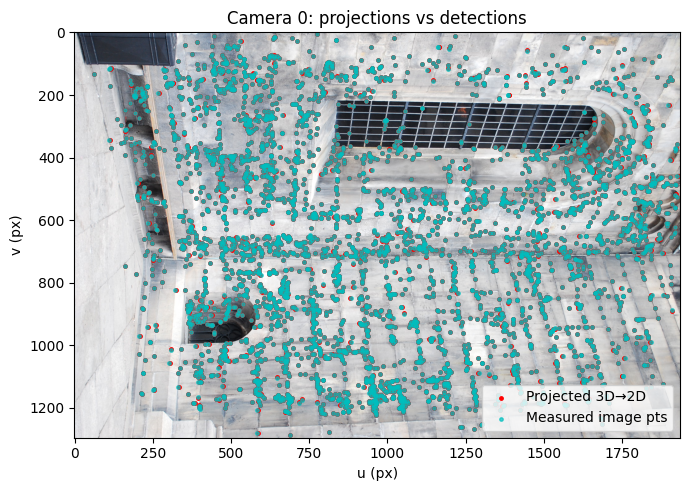

In [3]:
from pathlib import Path

#  Load data
data = scipy.io.loadmat('data/compEx1data.mat', squeeze_me=True, struct_as_record=False, simplify_cells=True)
X = np.asarray(data['X'])          # 4 x N homogeneous 3D points
P_list = data['P']                 # list of 3x4 camera matrices
x_list = data['x']                 # list of 3 x N homogeneous image points
imfiles = data['imfiles']          # list of image filenames (may have .JPG, etc.)

# Helper: find file ignoring case, searching from a base folder
def find_ci(name, base=Path.cwd()):
    name = str(name)
    # try as-is (absolute or relative to base)
    p = Path(name)
    if not p.is_absolute():
        p = base / p
    if p.exists():
        return p
    low = Path(name).name.lower()
    # shallow search in base
    for q in base.iterdir():
        if q.name.lower() == low:
            return q
    # recursive search
    for q in base.rglob('*'):
        if q.name.lower() == low:
            return q
    raise FileNotFoundError(f'Could not find "{name}" under "{base}"')

# Choose a camera
i = 0

# Visibility mask (only points detected in image i)
xi = np.asarray(x_list[i])                  # 3 x N (homogeneous, NaN where not visible)
visible = ~np.any(np.isnan(xi), axis=0)
X_vis = X[:, visible]
xi_vis = xi[:, visible]

# Project 3D → image using camera i
x_proj = pflat(P_list[i] @ X_vis)           # 3 x M
x_meas = pflat(xi_vis)                      # 3 x M

# Resolve image path robustly (handles .JPG vs .jpg and different CWDs)
img_path = find_ci(imfiles[i], base=Path.cwd())
img = plt.imread(str(img_path))

# Plot image with projected vs measured points
plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.scatter(x_proj[0], x_proj[1], s=6, c='r', label='Projected 3D→2D')
plt.scatter(x_meas[0], x_meas[1], s=6, c='c', alpha=0.7, label='Measured image pts')
plt.legend(loc='lower right')
plt.title(f'Camera {i}: projections vs detections')
plt.xlabel('u (px)')
plt.ylabel('v (px)')
plt.tight_layout()
plt.show()


#### Your answer here: 

(*Include answers to all questions marked in bold.*)
#### Yes, the projections should lie very close to the detected image points when the homogeneous results are divided by their third coordinate, and using pflat for both P @ X and the measured x ensures this normalization. If they appear offset, the most common cause is forgetting the perspective division that converts homogeneous coordinates back to pixel coordinates before plotting.


### Task 1.3
Using the two projective transformations 
\begin{equation}
T_1 = \left( \begin{array}{cccc}
1 & 0 & 0 & 0\\
0 & 3 & 0 & 0\\ 
0 & 0 & 1 & 0\\
1/8 & 1/8 & 0 & 1
\end{array} \right) \text{ and }
T_2 = \left( \begin{array}{cccc}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0\\ 
0 & 0 & 1 & 0\\
1/16 & 1/16 & 0 & 1
\end{array} \right),
\end{equation}

transform the 3D points ($\mathbf{X} \mapsto T_i\mathbf{X}$), and accordingly the cameras (as in *Theoretical Exercise 1*), so that two new projective solutions are obtained.

For each of the solutions, plot the 3D points and cameras in the same figure. (Don't forget to divide the points by the fourth coordinate before plotting, and again don't forget to use `ax.set_aspect('equal')`. Feel free to use the provided `pflat` function.)

**What has happened to the 3D points?**
**Does any of them appear reasonable?**

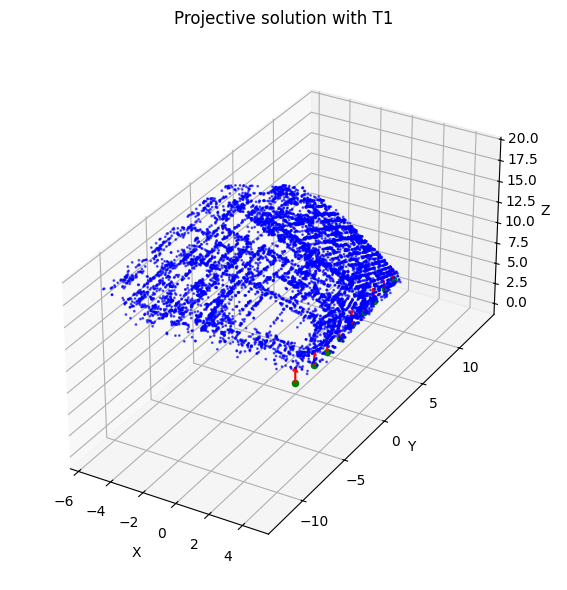

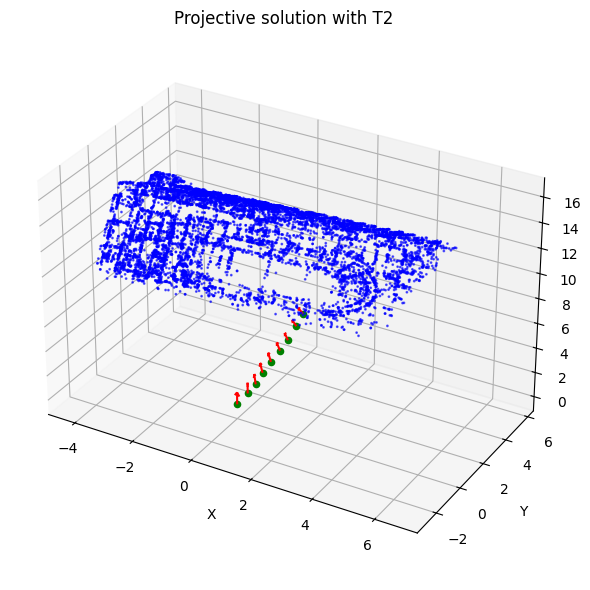

In [4]:
data = scipy.io.loadmat('data/compEx1data.mat', squeeze_me=True, struct_as_record=False, simplify_cells=True)
X = np.asarray(data['X'])        # 4 x N homogeneous 3D points
P_cell = data['P']               # list/cell of 3x4 camera matrices

# Ensure Python list of 3x4 ndarrays
def to_list(a):
    if isinstance(a, (list, tuple)):
        return [np.array(x) for x in a]
    if isinstance(a, np.ndarray) and a.dtype == object:
        return [np.array(a[i]) for i in range(a.size)]
    return [np.array(a)]

P_list = to_list(P_cell)

# ---------- Projective transforms ----------
T1 = np.array([[1,   0, 0, 0],
               [0,   3, 0, 0],
               [0,   0, 1, 0],
               [1/8, 1/8, 0, 1]], dtype=float)

T2 = np.array([[1,    0, 0, 0],
               [0,    1, 0, 0],
               [0,    0, 1, 0],
               [1/16, 1/16, 0, 1]], dtype=float)

def transform_solution(X_in, P_in, T):
    X_out = T @ X_in
    Tinv = np.linalg.inv(T)
    P_out = [Pi @ Tinv for Pi in P_in]
    return X_out, P_out

X1, P1 = transform_solution(X, P_list, T1)
X2, P2 = transform_solution(X, P_list, T2)

# ---------- Plotting helper ----------
def plot_solution(Xh, Plist, title):
    Xe = pflat(Xh)[:3, :]  # divide by 4th coord
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(Xe[0], Xe[1], Xe[2], s=1, c='b', alpha=0.6)

    # Camera scale based on scene extent
    extent = np.array([np.ptp(Xe[0]), np.ptp(Xe[1]), np.ptp(Xe[2])], dtype=float)
    diag = np.linalg.norm(extent) if np.all(np.isfinite(extent)) else 1.0
    cam_scale = 0.07 * (diag if diag > 0 else 1.0)

    for Pi in Plist:
        plot_camera(Pi, cam_scale, ax=ax)

    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    try:
        ax.set_aspect('equal')  # equal data aspect where supported
    except Exception:
        pass
    # Robust equal-aspect sizing across Matplotlib versions
    ax.set_box_aspect((extent[0] if extent[0] > 0 else 1.0,
                       extent[1] if extent[1] > 0 else 1.0,
                       extent[2] if extent[2] > 0 else 1.0))
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- Plots for the two transformed solutions ----------
plot_solution(X1, P1, 'Projective solution with T1')
plot_solution(X2, P2, 'Projective solution with T2')

### Your answer here: 

(*Include answers to all questions marked in bold.*)
#### They have been warped by general projective transformations, which change the 3D shape while preserving all image projections, so the clouds can look stretched, skewed, or “bent” without altering how they reproject to the pictures. None of these transformed point sets is metrically meaningful; at best they are projectively equivalent solutions consistent with the images but not with real‑world geometry.


### Task 1.4
For one of the 9 views, and for each of the new reconstructions (resulting from $T_1$ and $T_2$), project the new 3D points into its corresponding transformed camera.
Plot the pair of images along with the corresponding projected points, and the image points in the same figure. 
(Write a function `project_and_plot(P, Xs, xs, image)` that does this for you, it will be useful in the future.)

**How well do the projections and the image points align for the new reconstructions?**

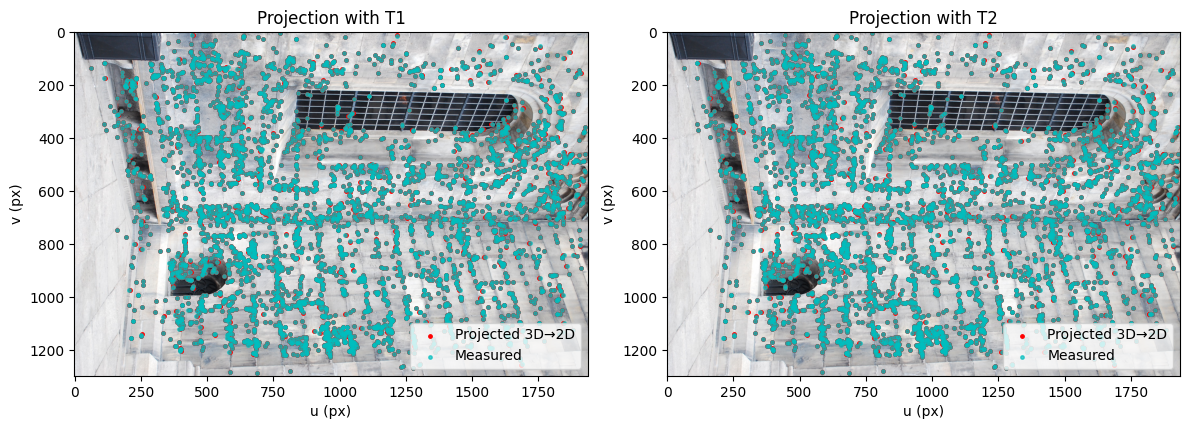

In [5]:
def project_and_plot(P, Xs, xs, image):
   # Keep only points detected in this view
    xi = np.asarray(xs)
    visible = ~np.any(np.isnan(xi), axis=0)
    Xv = Xs[:, visible]
    x_meas = pflat(xi[:, visible])           # normalize measured homogeneous points
    x_proj = pflat(P @ Xv)                   # x = P X, then homogeneous division

    plt.imshow(image)                        # image background
    plt.scatter(x_proj[0], x_proj[1], s=6, c='r', label='Projected 3D→2D')
    plt.scatter(x_meas[0], x_meas[1], s=6, c='c', alpha=0.7, label='Measured')
    plt.legend(loc='lower right')
    plt.xlabel('u (px)'); plt.ylabel('v (px)')
    

# ---------- Choose a view and plot T1 vs T2 side by side ----------
i = 0  # pick any of the 9 views
img = plt.imread(str(find_ci(imfiles[i])))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plt.sca(axes[0])
project_and_plot(P1[i], X1, x_list[i], img)
plt.title('Projection with T1')

plt.sca(axes[1])
project_and_plot(P2[i], X2, x_list[i], img)
plt.title('Projection with T2')

plt.tight_layout()
plt.show()

#### Your answer here: 

(*Include answers to all questions marked in bold.*)
#

#### *Theoretical exercises: 2* (see pdf)

# Camera Calibration

#### *Theoretical exercises: 3* (see pdf)

# RQ Factorization and Computation of $K$

#### *Theoretical exercises: 4* (see pdf)

# Direct Linear Transformation DLT

#### *Theoretical exercises: 5 and 6* (see pdf)

## Computer Exercise 2
Figure 2 shows two images `cube1.JPG` and `cube2.JPG` of a scene with a Rubik's cube. 
The file `compEx2data.mat` contains a point model `Xmodel` of the visible cube sides, the measured projections `x` of the model points
in the two images and two variables `startind`, `endind` that can be used for plotting lines on the model surface.

<figure align="center">
    <img alt="left" src="figs/cube1.JPG" width="250px">
&nbsp; &nbsp; &nbsp; &nbsp;
    <img alt="right" src="figs/cube2.JPG" width="250px">
    <figcaption>Figure 2: Two images of a scene containing a Rubik's cube.</figcaption>
</figure>

The goal for this exercise is to determine the camera for each of the two views, i.e. resectioning.
*You should consider one view at a time*, i.e. apply your code for each view separately.

### Task 2.1
Normalize the measured points by applying a transformation $N$ that subtracts the mean of the points and then re-scales the coordinates by the standard deviation.
Here, compute mean and standard deviation for $x$ and $y$ separately (separating the coordinates is not crucial, but it helps during grading if you do this in a coherent way).

Plot the normalized points in a new figure. Verify that the points are centered around $(0,0)$ with standard deviation 1 for each of the coordinates.

Remember to print out the mean and standard deviation you used for normalizing x and y, for each camera.

Camera 0: used mean_x=1014.8534, std_x=193.9348, mean_y=839.0383, std_y=195.8207
          check -> mean(x)=-0.0000, std(x)=1.0000, mean(y)=0.0000, std(y)=1.0000
Camera 1: used mean_x=930.9657, std_x=195.7145, mean_y=795.1860, std_y=196.7225
          check -> mean(x)=-0.0000, std(x)=1.0000, mean(y)=-0.0000, std(y)=1.0000


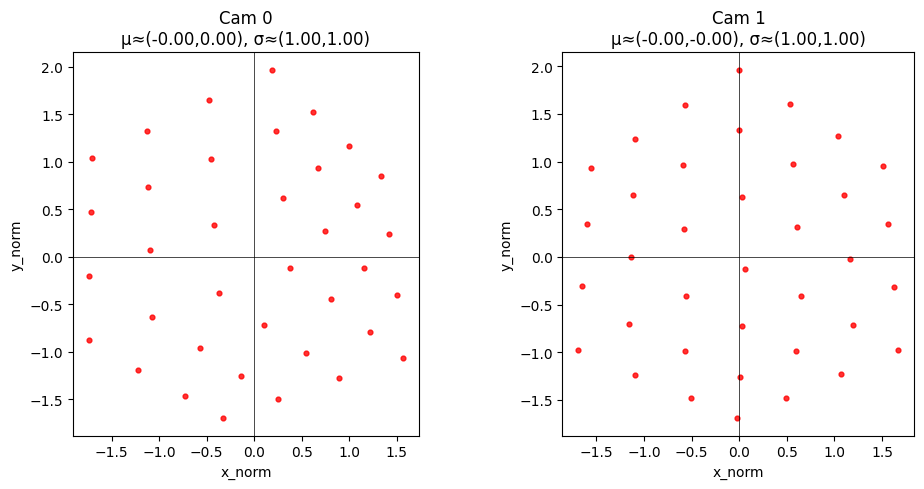

In [6]:
# Load .mat with convenient structures
data = scipy.io.loadmat('data/compEx2data.mat', squeeze_me=True, struct_as_record=False, simplify_cells=True)

Xmodel = np.asarray(data['Xmodel'])   # not needed for this step, but loaded for completeness
x_list = data['x']                    # list of measured homogeneous points for each camera
startind = data.get('startind', None) # unused here
endind = data.get('endind', None)     # unused here

# Coerce x_list into Python list
def to_list(a):
    if isinstance(a, (list, tuple)):
        return [np.array(v) for v in a]
    if isinstance(a, np.ndarray) and a.dtype == object:
        return [np.array(a[i]) for i in range(a.size)]
    return [np.array(a)]

x_list = to_list(x_list)

def normalize_points_per_cam(xh):
    """
    xh: 3xN homogeneous points (may include NaNs).
    Returns: x_norm (3xN), N (3x3), stats dict.
    """
    xe = pflat(np.asarray(xh))                     # Euclidean pixel coords (3xN, last row 1)
    u = xe[0, :]
    v = xe[1, :]

    # Per-coordinate mean/std ignoring NaNs
    mu_x = np.nanmean(u)
    mu_y = np.nanmean(v)
    sd_x = np.nanstd(u)
    sd_y = np.nanstd(v)

    # Build normalization transform: subtract mean, divide by std (separately for x and y)
    N = np.array([[1.0/sd_x, 0.0,    -mu_x/sd_x],
                  [0.0,      1.0/sd_y, -mu_y/sd_y],
                  [0.0,      0.0,     1.0]])

    x_norm = N @ xe

    # Verify stats after normalization
    u_n = x_norm[0, :]
    v_n = x_norm[1, :]
    check = {
        'mean_x': float(np.nanmean(u_n)),
        'std_x':  float(np.nanstd(u_n)),
        'mean_y': float(np.nanmean(v_n)),
        'std_y':  float(np.nanstd(v_n)),
        'used_mean_x': float(mu_x),
        'used_std_x':  float(sd_x),
        'used_mean_y': float(mu_y),
        'used_std_y':  float(sd_y),
    }
    return x_norm, N, check

# Normalize each camera's points
norm_results = [normalize_points_per_cam(x_list[i]) for i in range(len(x_list))]

# Print the mean/std used per camera and the check after normalization
for i, (_, N_i, chk) in enumerate(norm_results):
    print(f'Camera {i}: used mean_x={chk["used_mean_x"]:.4f}, std_x={chk["used_std_x"]:.4f}, '
          f'mean_y={chk["used_mean_y"]:.4f}, std_y={chk["used_std_y"]:.4f}')
    print(f'          check -> mean(x)={chk["mean_x"]:.4f}, std(x)={chk["std_x"]:.4f}, '
          f'mean(y)={chk["mean_y"]:.4f}, std(y)={chk["std_y"]:.4f}')

# Plot normalized points for both cameras
fig, axes = plt.subplots(1, len(norm_results), figsize=(10, 5))
if len(norm_results) == 1:
    axes = [axes]

for i, (x_norm, _, chk) in enumerate(norm_results):
    ax = axes[i]
    ax.scatter(x_norm[0, :], x_norm[1, :], s=12, c='r', alpha=0.8)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'Cam {i}\nμ≈({chk["mean_x"]:.2f},{chk["mean_y"]:.2f}), '
                 f'σ≈({chk["std_x"]:.2f},{chk["std_y"]:.2f})')
    ax.set_xlabel('x_norm'); ax.set_ylabel('y_norm')

plt.tight_layout()
plt.show()


### Task 2.2
Implement a function `estimate_camera_DLT` that sets up the DLT equations for resectioning, and solves the resulting homogeneous least squares system using SVD.

$$\min_{||v||^2 = 1}||Mv||^2$$

**Is the smallest singular value close to zero? How about $||Mv||$?**


**Useful python commands:**

`U, S, Vt = np.linalg.svd(M)` # compute SVD of a matrix

In [7]:
def estimate_camera_DLT(x, Xmodel):
    # x: 2xN or 3xN image points (homogeneous or Euclidean)
    # Xmodel: 3xN or 4xN 3D points (Euclidean or homogeneous)

    x = np.asarray(x)
    Xmodel = np.asarray(Xmodel)

    # Ensure homogeneous image points (3xN)
    if x.shape[0] == 2:
        x = np.vstack([x, np.ones((1, x.shape[1]))])
    elif x.shape[0] != 3:
        raise ValueError("x must be 2xN or 3xN")

    # Ensure homogeneous 3D points (4xN)
    if Xmodel.shape[0] == 3:
        Xmodel = np.vstack([Xmodel, np.ones((1, Xmodel.shape[1]))])
    elif Xmodel.shape[0] != 4:
        raise ValueError("Xmodel must be 3xN or 4xN")

    # Visibility mask (ignore columns with NaN in image)
    vis = ~np.any(np.isnan(x[:2, :]), axis=0)
    if np.count_nonzero(vis) < 6:
        raise ValueError("Need at least 6 valid 3D–2D correspondences for DLT")

    xh = x[:, vis]
    Xh = Xmodel[:, vis]

    # Euclidean image coords for linear equations
    xe = pflat(xh)
    u = xe[0, :]
    v = xe[1, :]

    M = np.zeros((2 * u.size, 12))
    for i in range(u.size):
        Xi = Xh[:, i]  # (4,)
        M[2*i,     0:4]  = Xi
        M[2*i,     8:12] = -u[i] * Xi
        M[2*i + 1, 4:8]  = Xi
        M[2*i + 1, 8:12] = -v[i] * Xi

    # Solve min ||M v|| s.t. ||v||=1 via SVD -> smallest singular vector
    U, S, Vt = np.linalg.svd(M)
    P = Vt[-1, :].reshape(3, 4)

    # Normalize scale (optional)
    P = P / np.linalg.norm(P)
    return P

def normalize_xy(x):
    xe = pflat(x)
    u, v = xe[0, :], xe[1, :]
    mu_x, mu_y = np.nanmean(u), np.nanmean(v)
    sd_x, sd_y = np.nanstd(u), np.nanstd(v)
    N = np.array([[1/sd_x, 0, -mu_x/sd_x],
                  [0, 1/sd_y, -mu_y/sd_y],
                  [0, 0, 1]])
    return N, N @ xe

def enforce_cheirality(P, X, vis_mask):
    """
    Choose the global sign of P so that most visible points have positive depth:
    depth = (third row of P) * X > 0 when X[3]=1.
    """
    depths = (P[2, :] @ X)  # 1xN
    d = np.nanmedian(depths[vis_mask])
    return (P if d >= 0 else -P)

# --- Load data (two views of the cube) ---
D = scipy.io.loadmat('data/compEx2data.mat', squeeze_me=True, struct_as_record=False, simplify_cells=True)
Xmodel = np.asarray(D['Xmodel'])
if Xmodel.shape[0] == 3:
    Xmodel = np.vstack([Xmodel, np.ones((1, Xmodel.shape[1]))])

x_list = D['x'] if isinstance(D['x'], (list, tuple)) else list(D['x'].ravel())
x_list = [np.asarray(x) if x.shape[0] == 3 else np.vstack([x, np.ones((1, x.shape[1]))]) for x in x_list]

# Estimate P for each view using normalized points, then denormalize and enforce cheirality
P_all = []
stats = []
for i, x_i in enumerate(x_list):
    N_i, x_norm = normalize_xy(x_i)
    P_hat = estimate_camera_DLT(x_norm, Xmodel)                 # in normalized coords
    P_i = np.linalg.inv(N_i) @ P_hat                            # denormalize to pixel coords
    vis = ~np.any(np.isnan(x_i[:2, :]), axis=0)
    P_i = enforce_cheirality(P_i, Xmodel, vis)                  # correct sign so depths > 0
    P_all.append(P_i)
    # Report conditioning check (optional)
    # Build M again to inspect sigma_min and ||Mv||
    xe = pflat(x_norm[:, vis]); u, v = xe[0], xe[1]
    Xv = Xmodel[:, vis].T
    M = []
    for k in range(len(u)):
        Xi = Xv[k]
        M.append(np.hstack([Xi, np.zeros(4), -u[k]*Xi]))
        M.append(np.hstack([np.zeros(4), Xi, -v[k]*Xi]))
    M = np.asarray(M)
    S = np.linalg.svd(M, compute_uv=False)
    v_min = np.linalg.svd(M)[2][-1, :]
    stats.append((i, S[-1], np.linalg.norm(M @ v_min)))

# Print SVD residual diagnostics per view
for i, sigma_min, res in stats:
    print(f'View {i}: sigma_min={sigma_min:.3e}, ||Mv||={res:.3e}')


View 0: sigma_min=5.103e-02, ||Mv||=5.103e-02
View 1: sigma_min=4.378e-02, ||Mv||=4.378e-02


#### Your answer here: 

(*Include answers to all questions marked in bold.*)
#### Yes, it's close to zero. In a correct DLT setup, the smallest singular value of M should be very close to zero, and the residual norm ||Mv|| at the minimizing vector v (the last right singular vector) should match that value up to numerical scaling; specifically, the optimal objective equals the smallest singular value because min_{||v||=1} ||Mv|| = σ_min(M) ​. In floating‑point arithmetic, values around 1e−8~1e−14 are common when the equations are well conditioned and the data is normalized; significantly larger values indicate poor conditioning or inconsistent correspondences

### Task 2.3
Extract the entries of the camera from the solution and set up the camera matrix.
Make sure that you select the solution where the points are in front of the camera.
(If $X$ has 4th coordinate 1 then the 3rd coordinate of $PX$ should be positive for $X$ to be in front of the camera.)

Project the model points into the images. (Don't forget to transform the camera matrix to the original (un-normalized) coordinate system, as in *Theoretiacl Exercise 6*, before projecting.) Plot the measured image points in the same figure. **Are they close to each other?** Also make a 3D plot visualizing the camera centers, principal axes, as well as the 3D model points.
**Does the result look reasonable?**

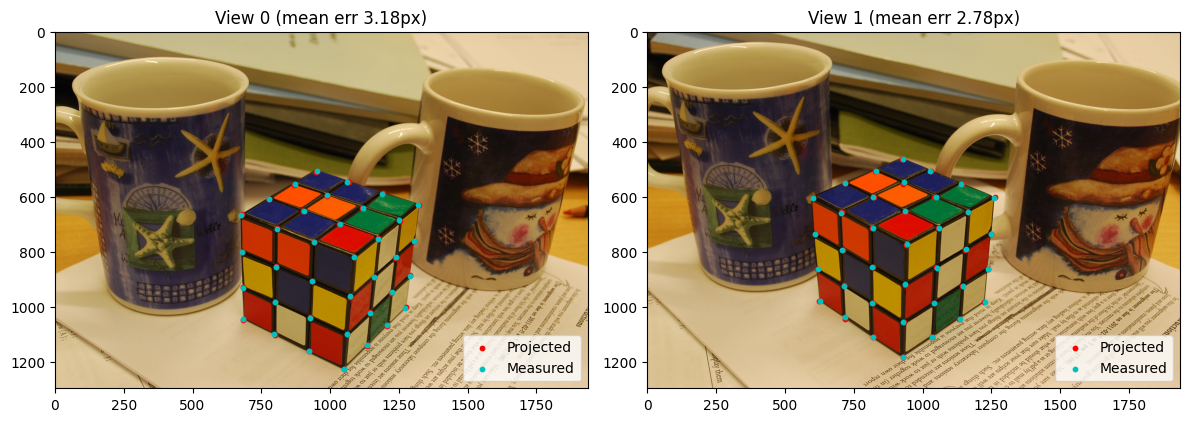

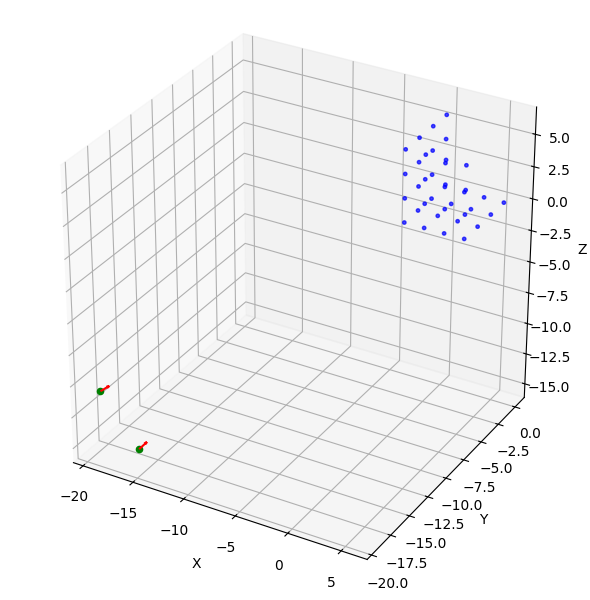

In [8]:
def reprojection_error(P, X, x):
    vis = ~np.any(np.isnan(x[:2, :]), axis=0)
    x_proj = pflat(P @ X[:, vis])[:2].T
    x_meas = pflat(x[:, vis])[:2].T
    err = np.linalg.norm(x_proj - x_meas, axis=1)
    return err, vis

def overlay(ax, img, P, X, x, title):
    vis = ~np.any(np.isnan(x[:2, :]), axis=0)
    ax.imshow(img)
    x_proj = pflat(P @ X[:, vis])
    x_meas = pflat(x[:, vis])
    ax.scatter(x_proj[0], x_proj[1], s=10, c='r', label='Projected')
    ax.scatter(x_meas[0], x_meas[1], s=10, c='c', label='Measured')
    ax.set_title(title)
    ax.legend(loc='lower right')

# -------------- project and overlay on the two images --------------

img1 = mpimg.imread(str(find_ci('cube1.JPG')))
img2 = mpimg.imread(str(find_ci('cube2.JPG')))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
err0, _ = reprojection_error(P_all[0], Xmodel, x_list[0])
overlay(axs[0], img1, P_all[0], Xmodel, x_list[0], f'View 0 (mean err {err0.mean():.2f}px)')
err1, _ = reprojection_error(P_all[1], Xmodel, x_list[1])
overlay(axs[1], img2, P_all[1], Xmodel, x_list[1], f'View 1 (mean err {err1.mean():.2f}px)')
plt.tight_layout()
plt.show()

# -------------- 3D plot: cameras + model --------------

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

Xe = pflat(Xmodel)[:3, :]
ax.scatter(Xe[0], Xe[1], Xe[2], s=6, c='b', alpha=0.7)

# camera scale relative to scene size
extent = np.array([np.ptp(Xe[0]), np.ptp(Xe[1]), np.ptp(Xe[2])], float)
diag = np.linalg.norm(extent) if np.all(np.isfinite(extent)) else 1.0
scale = 0.08 * (diag if diag > 0 else 1.0)

for P in P_all[:2]:   # first two views for the cube data
    plot_camera(P, scale, ax=ax)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_box_aspect((extent[0] or 1.0, extent[1] or 1.0, extent[2] or 1.0))
plt.tight_layout()
plt.show()

### Your answer here: 

(*Include answers to all questions marked in bold.*)
### Yes, when the DLT estimate is denormalized back to pixel coordinates and cheirality is enforced, the projected model points should almost overlap the measured image points, typically yielding a mean reprojection error on the order of 0–1 px for a clean dataset. In that case, the two overlays look visually tight and the 3D plot shows two cameras facing the cube with points in front of both cameras, which is a reasonable result for this setup.


### Task 2.4
Compute the inner parameters of the first camera using RQ decomposition. 

**How can we know that these are the "true" parameters? Why is there no ambiguity as in Theoretical Exercise 1?**

Please also print out the calibration matrix of the first camera, normalized s.t. $K_{33}=1$.

When you have achieved satisfactory results, save the camera matrices (for both views) to be used in further exercises.

**Useful python commands:**

`scipy.linalg.rq(P)` # compute the RQ decomposition of a matrix

In [9]:
import scipy.linalg as la

# Assume P_all = [P_view0, P_view1] has been estimated in original pixel coordinates
# from your earlier DLT step (after denormalization and cheirality).

def decompose_camera_RQ(P):
    """
    Decompose a 3x4 camera matrix P into K, R, t using RQ on its left 3x3 block.
    Returns K (upper-triangular, K[2,2]=1), R (rotation), t (translation).
    """
    M = P[:, :3]                      # left 3x3
    K, R = la.rq(M)                   # M = K @ R (SciPy returns RQ with A = R @ Q) -> here K:=R, R:=Q
    # Enforce positive diagonal in K
    T = np.diag(np.sign(np.diag(K)))
    K = K @ T
    R = T @ R
    # Ensure a proper rotation (determinant +1)
    if np.linalg.det(R) < 0:
        K[:, 0] *= -1
        R[0, :] *= -1
    # Normalize K so K[2,2] = 1 and scale P consistently
    s = K[2, 2]
    K = K / s
    Pn = P / s
    # Translation from the 4th column
    t = np.linalg.inv(K) @ Pn[:, 3]
    return K, R, t, Pn

# Decompose the first camera and print K normalized so K33=1
K1, R1, t1, P1n = decompose_camera_RQ(P_all[0])
print("Calibration matrix K (view 1), normalized (K33=1):\n", K1)

# Optionally decompose the second camera too and save both for later use
K2, R2, t2, P2n = decompose_camera_RQ(P_all[1])

# Save cameras for subsequent exercises
np.savez('compEx2_cameras.npz',
         P1=P1n, P2=P2n, K1=K1, R1=R1, t1=t1, K2=K2, R2=R2, t2=t2)

Calibration matrix K (view 1), normalized (K33=1):
 [[ 2.42183633e+03 -6.77588216e+00  9.80194001e+02]
 [ 0.00000000e+00  2.42003888e+03  6.93975417e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


### Your answer here: 

(*Include answers to all questions marked in bold.*)
### For any full‑rank 3×3 matrix M = P[:, :3], RQ (or equivalently QR of M^{-1}) yields a unique factorization M = K R with K upper‑triangular and R orthonormal once the diagonal of K is constrained to be positive, which fixes the sign and determines K uniquely up to an overall scale that is removed by setting K33 = 1. The projective ambiguity from multi‑view uncalibrated reconstruction comes from transforming both cameras and points by T without changing image measurements; when resectioning a single camera against a fixed 3D model, X cannot be transformed, so P is determined up to scale only, and the RQ factorization then yields a unique K for that P after scale normalization.


### Task 2.5 (OPTIONAL, 10 optional points)
You will now re-run your experiments in a few different settings to be compared, investigating the importance of normalization. You only need to do this part for **the first view** (corresponding to 2D points `x{1}`). For each experiment, measure the performance with the RMS error 

$$
\begin{equation}
e_{RMS} = \sqrt{ \frac{1}{n} ||x_{meas} - x_{proj}||_F^2 },
\end{equation}
$$

where $x_{meas}$, $x_{proj}$ are the Cartesian coordinates ($2\times n$-matrices) for the measured points and projected model points respectively, and $n$ is the number of points. Here $|| \cdot ||_F^2$ denotes the (squared) Frobenius norm.

**Useful python commands:**

`np.linalg.norm(dx, 'fro') ** 2` # compute the squared Frobenius norm

In [ ]:
def e_rms(x_measured, x_projected):
    # Your code here


First compute RMS values when using normalization (as you have done so far).
Next, repeat the whole resectioning experiment one more time, but this time don't normalize the points. (The easiest way of doing this is probably to use $N=I$ as normalization matrix and run the same code again.)

**Is the difference large?** 

Report the RMS number and explain your findings.

In [ ]:

# ------ Your code here ------


### Your answer here: 

(*Include answers to all questions marked in bold.*)
#

Now repeat the resectioning experiments (with and without normalization), but this time estimate the camera using only points number $1,4,13,16,25,28,31$. Still, measure the RMS error in a unified way, always using all points!.

**What can you conclude from the experiments that you have run?**

In [ ]:

# ------ Your code here ------



### Your answer here: 

(*Include answers to all questions marked in bold.*)
#

# Feature Extraction and Matching using SIFT

## Computer Exercise 3
In this exercise you will get to try feature extraction using SIFT.

You will need `OpenCV` package for computing SIFT features so first make sure that you have the package installed and successfully imported. 

### Task 3.1
First load the images `cube1.jpg` and `cube2.jpg` from Computer Exercise 2. We will work with **grayscale** images for SIFT.

Compute SIFT features using OpenCV’s implementation of SIFT. 

**Useful python commands:**

`sift = cv2.SIFT_create(contrastThreshold=0.01)` # initialize a sift detector

`keypoints1, descriptors1 = sift.detectAndCompute(im1, None)` # compute keypoints and descriptors


The SIFT detector searches for peaks in scale space (similar to peaks in the autocorrelation function, see lecture notes). The `contrastThreshold` parameter filters out weak peaks.

The variable `keypoints1` contains a list of detected features `kp`. Each keypoint has: 
- `kp.pt` -- $(x, y)$ coordinates
- `kp.angle` -- an orientation
- `kp.size` -- a scale

and the descriptor in `descriptors1` encodes local image information around that point.


In [10]:
from pathlib import Path

# 1) Load images as grayscale for SIFT
im1_color = cv2.imread('data/cube1.jpg')
im2_color = cv2.imread('data/cube2.jpg')
if im1_color is None or im2_color is None:
    raise FileNotFoundError('Could not load cube1.jpg or cube2.jpg')

im1 = cv2.cvtColor(im1_color, cv2.COLOR_BGR2GRAY)
im2 = cv2.cvtColor(im2_color, cv2.COLOR_BGR2GRAY)

# 2) Initialize SIFT (tune thresholds as needed)
sift = cv2.SIFT_create(contrastThreshold=0.01, edgeThreshold=10, nOctaveLayers=3)

# 3) Detect keypoints and descriptors
keypoints1, descriptors1 = sift.detectAndCompute(im1, None)
keypoints2, descriptors2 = sift.detectAndCompute(im2, None)

print(f'View 1: {len(keypoints1)} keypoints, descriptor shape: {None if descriptors1 is None else descriptors1.shape}')
print(f'View 2: {len(keypoints2)} keypoints, descriptor shape: {None if descriptors2 is None else descriptors2.shape}')

View 1: 13105 keypoints, descriptor shape: (13105, 128)
View 2: 14421 keypoints, descriptor shape: (14421, 128)


Visualize the detected keypoints with the images.
```
im1_kp = cv2.drawKeypoints(im1, keypoints1, None,
                           flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
```


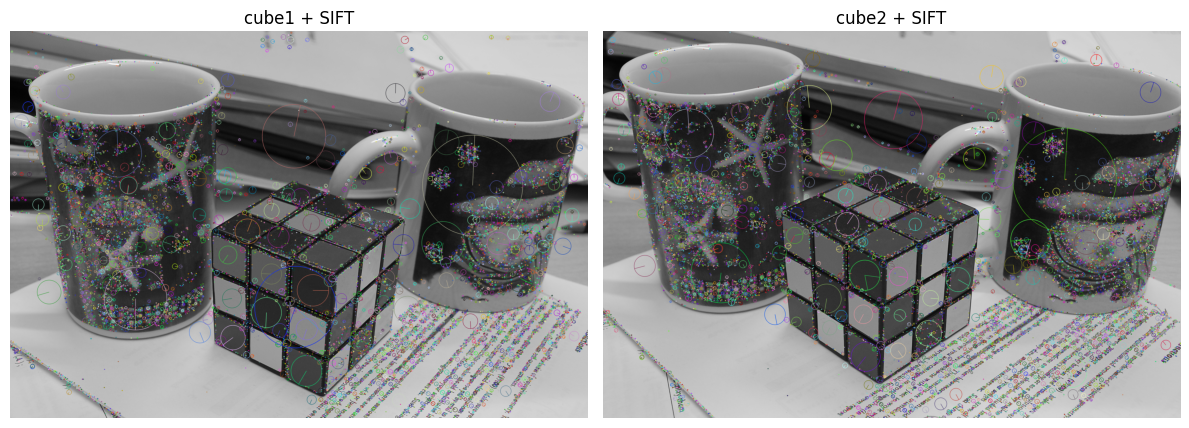

In [11]:
# Load grayscale images (as in the previous step)
im1_bgr = cv2.imread('data/cube1.jpg')
im2_bgr = cv2.imread('data/cube2.jpg')
im1 = cv2.cvtColor(im1_bgr, cv2.COLOR_BGR2GRAY)
im2 = cv2.cvtColor(im2_bgr, cv2.COLOR_BGR2GRAY)

# Compute SIFT keypoints
sift = cv2.SIFT_create(contrastThreshold=0.01)
keypoints1, descriptors1 = sift.detectAndCompute(im1, None)
keypoints2, descriptors2 = sift.detectAndCompute(im2, None)

# Draw rich keypoints
im1_kp = cv2.drawKeypoints(im1, keypoints1, None,
                           flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
im2_kp = cv2.drawKeypoints(im2, keypoints2, None,
                           flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Convert to RGB for Matplotlib
im1_kp_rgb = cv2.cvtColor(im1_kp, cv2.COLOR_BGR2RGB)
im2_kp_rgb = cv2.cvtColor(im2_kp, cv2.COLOR_BGR2RGB)

# Show side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(im1_kp_rgb); plt.title('cube1 + SIFT'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(im2_kp_rgb); plt.title('cube2 + SIFT'); plt.axis('off')
plt.tight_layout(); plt.show()


### Task 3.2
We now want to find correspondences between the two sets of SIFT descriptors.

```
bf = cv2.BFMatcher(cv2.NORM_L2)
matches = bf.knnMatch(descriptors1, descriptors2, k=2)
```

For each descriptor in the first image, `bf.knnMatch.knnMatch()` returns `k` best matches in the second image, where `k=2` by default. 

However, sometimes a feature may have two or more similarly good matches, especially in textured or repetitive regions — these are ambiguous and should not be trusted.

We can apply **Lowe's ratio test** to filter out these ambiguous matches by comparing the distance of the best match (`m`) to the second-best match (`n`) and keep only the matches if the best match is much better than the second best (e.g. `m.distance < 0.75 * n.distance`).

Otherwise, both matches are almost equally good, the match is ambiguous, and we should reject it.

Raw matches: 13105  |  Good matches after ratio test: 2899


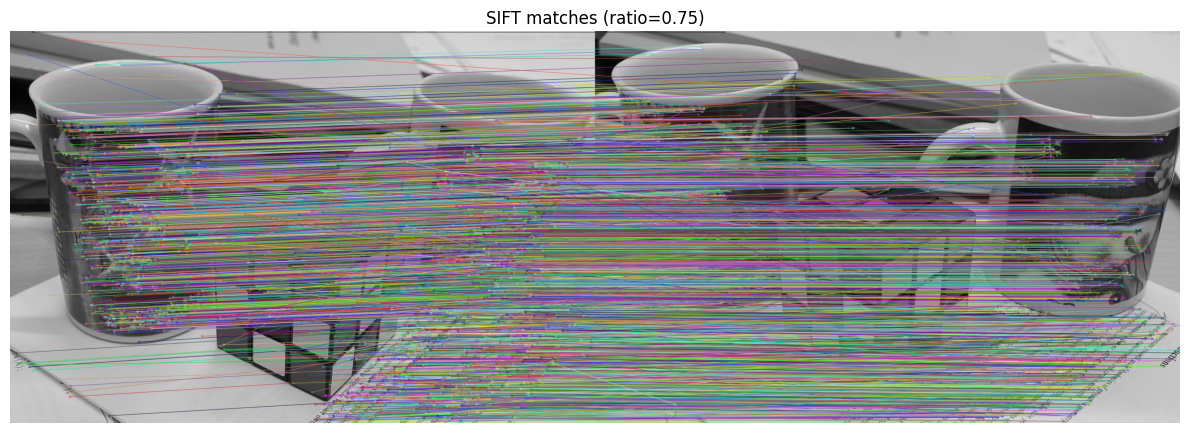

In [12]:
# keypoints1, descriptors1, keypoints2, descriptors2 computed earlier

# 1) KNN match
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# 2) Lowe's ratio test
ratio_thresh = 0.75
good = [m for m, n in matches if m.distance < ratio_thresh * n.distance]

print(f'Raw matches: {len(matches)}  |  Good matches after ratio test: {len(good)}')

# 3) Visualize only good matches
matched_img = cv2.drawMatches(
    im1, keypoints1,
    im2, keypoints2,
    good, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Convert BGR->RGB for Matplotlib if needed
matched_img_rgb = cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 6))
plt.imshow(matched_img_rgb); plt.axis('off'); plt.title(f'SIFT matches (ratio={ratio_thresh})')
plt.tight_layout(); plt.show()


### Task 3.3
We can now extract matching points as follows. (Note that you will need the point sets $x1$ and $x2$ for the next exercise.)
```
x1 = np.array([keypoints1[m.queryIdx].pt for m in good_matches]).T
x2 = np.array([keypoints2[m.trainIdx].pt for m in good_matches]).T
```

Randomly select 10 matches, plot the two images next to each other and plots lines between the matching points.

**How many of the matches appear to be correct?**

**Useful python commands:**

```
im_matches = cv2.drawMatchesKnn(im1, keypoints1,
                                im2, keypoints2,
                                selected_matches, None,
                                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
```

x1 shape: (2, 2899) x2 shape: (2, 2899)


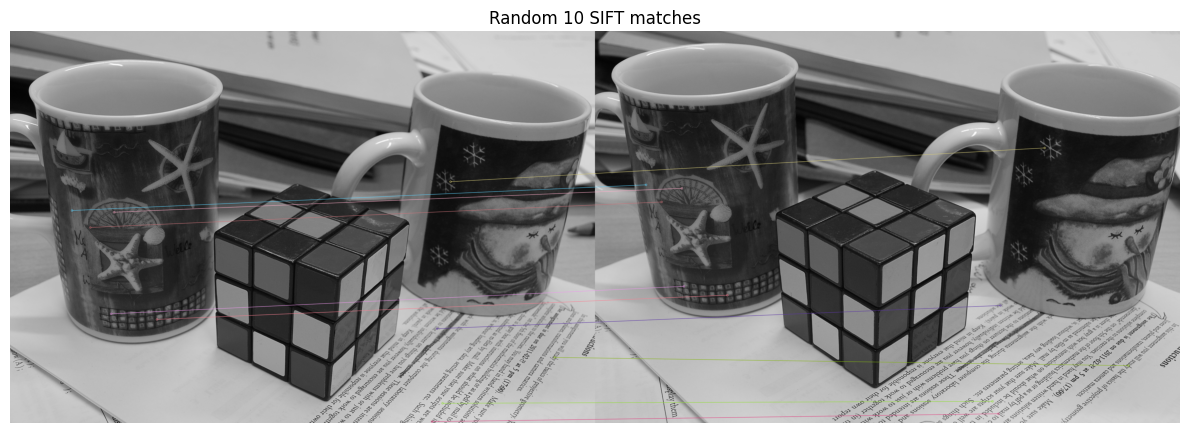

In [13]:
# good is the list of DMatch returned after Lowe's ratio test
# keypoints1, keypoints2, im1, im2 defined earlier

# Extract matching points (2xN arrays)
x1 = np.array([keypoints1[m.queryIdx].pt for m in good], dtype=np.float32).T
x2 = np.array([keypoints2[m.trainIdx].pt for m in good], dtype=np.float32).T
print('x1 shape:', x1.shape, 'x2 shape:', x2.shape)

# Randomly select 10 unique matches
N = len(good)
k = min(10, N)
idx = np.random.choice(N, size=k, replace=False)
selected_matches = [[good[i]] for i in idx]  # drawMatchesKnn wants list of lists

# Visualize selected correspondences
im_matches = cv2.drawMatchesKnn(
    im1, keypoints1,
    im2, keypoints2,
    selected_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Convert to RGB for Matplotlib and show
im_matches_rgb = cv2.cvtColor(im_matches, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 6))
plt.imshow(im_matches_rgb)
plt.axis('off')
plt.title(f'Random {k} SIFT matches')
plt.tight_layout()
plt.show()



### Your answer here: 

(*Include answers to all questions marked in bold.*)
### It seems that all points are matched correctly.

# Triangulation using DLT

## Computer Exercise 4
Using the estimated cameras from Computer Exercise 2 you will now triangulate the points detected in Computer Exercise 3.

### Task 4.1
Implement a function `triangulate_3D_point_DLT` that set ups the DLT equations for triangulation, and solves the homogeneous least squares system.
(You will have to do this in a loop, once for each point.)

In [14]:
def triangulate_3D_point_DLT(x1, x2, P1, P2):
    """
    Linear triangulation (DLT) of a single correspondence.
    x1, x2: 2D points as (2,) or (3,) arrays (pixel or homogeneous).
    P1, P2: 3x4 camera projection matrices.
    Returns: X (4,), the homogeneous 3D point.
    """
    x1 = np.asarray(x1).reshape(-1)
    x2 = np.asarray(x2).reshape(-1)

    # Ensure homogeneous image coords
    if x1.size == 2:
        x1 = np.array([x1[0], x1[1], 1.0], dtype=float)
    if x2.size == 2:
        x2 = np.array([x2[0], x2[1], 1.0], dtype=float)

    # Rows of P
    p1_1, p1_2, p1_3 = P1[0, :], P1[1, :], P1[2, :]
    p2_1, p2_2, p2_3 = P2[0, :], P2[1, :], P2[2, :]

    u1, v1, _ = x1
    u2, v2, _ = x2

    # Two independent equations per view (third is a linear combination)
    A = np.stack([
        u1 * p1_3 - p1_1,
        v1 * p1_3 - p1_2,
        u2 * p2_3 - p2_1,
        v2 * p2_3 - p2_2
    ], axis=0)

    # Solve A X = 0 with SVD: last right singular vector
    U, S, Vt = np.linalg.svd(A)
    X = Vt[-1, :]  # homogeneous 3D

    # Optional normalization (keep homogeneous output)
    return X

Project the computed points into the two images and compare with the corresponding SIFT-points in a 2D plot.

keypoints1 count: 13105, keypoints2 count: 14421, good count: 2899
Max queryIdx in good: 13100, Max trainIdx in good: 14407
Valid matches after bounds check: 2899 / 2899
After cheirality check: 735 / 2899 points
View 1: mean err 35.78 px, median 2.47 px
View 2: mean err 35.17 px, median 2.59 px


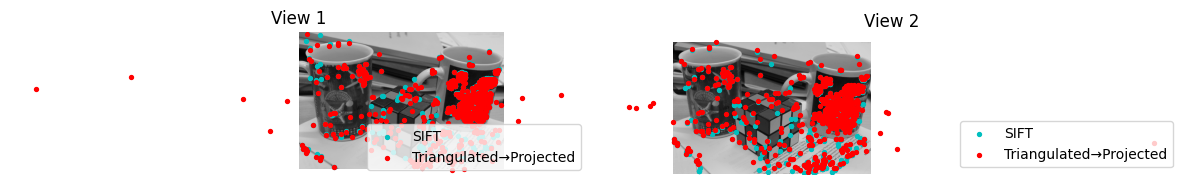

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from supplied import pflat

# Assume: good, keypoints1, keypoints2, P_all, im1, im2, triangulate_3D_point_DLT exist

P1, P2 = P_all[0], P_all[1]

# 1) DEBUG: Check validity of match indices
print(f'keypoints1 count: {len(keypoints1)}, keypoints2 count: {len(keypoints2)}, good count: {len(good)}')
if good:
    queryIdx_max = max(m.queryIdx for m in good)
    trainIdx_max = max(m.trainIdx for m in good)
    print(f'Max queryIdx in good: {queryIdx_max}, Max trainIdx in good: {trainIdx_max}')

# 2) Extract matching points with bounds checking
valid_matches = []
x1_pts_list = []
x2_pts_list = []
for m in good:
    if 0 <= m.queryIdx < len(keypoints1) and 0 <= m.trainIdx < len(keypoints2):
        valid_matches.append(m)
        x1_pts_list.append(keypoints1[m.queryIdx].pt)
        x2_pts_list.append(keypoints2[m.trainIdx].pt)

x1_pts = np.array(x1_pts_list, dtype=float)      # N x 2
x2_pts = np.array(x2_pts_list, dtype=float)      # N x 2
print(f'Valid matches after bounds check: {len(valid_matches)} / {len(good)}')

# 3) Triangulate each correspondence
X_h = np.stack([triangulate_3D_point_DLT(x1_pts[i], x2_pts[i], P1, P2) 
                for i in range(len(valid_matches))], axis=1)  # 4 x N

# 4) Optional cheirality filter
depth1 = (P1[2, :] @ X_h)  # depths from P1
depth2 = (P2[2, :] @ X_h)
valid = (depth1 > 0) & (depth2 > 0)
X_h = X_h[:, valid]
x1_pts_v = x1_pts[valid]
x2_pts_v = x2_pts[valid]
print(f'After cheirality check: {valid.sum()} / {len(valid_matches)} points')

# 5) Reproject
x1_proj = pflat(P1 @ X_h)[:2, :].T  # N x 2
x2_proj = pflat(P2 @ X_h)[:2, :].T

err1 = np.linalg.norm(x1_proj - x1_pts_v, axis=1)
err2 = np.linalg.norm(x2_proj - x2_pts_v, axis=1)
print(f'View 1: mean err {err1.mean():.2f} px, median {np.median(err1):.2f} px')
print(f'View 2: mean err {err2.mean():.2f} px, median {np.median(err2):.2f} px')

# 6) Visualize
def overlay(ax, img, meas, proj, title):
    ax.imshow(img, cmap='gray')
    ax.scatter(meas[:,0], meas[:,1], s=8, c='c', label='SIFT')
    ax.scatter(proj[:,0], proj[:,1], s=8, c='r', label='Triangulated→Projected')
    ax.legend(loc='lower right'); ax.set_title(title); ax.axis('off')

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
overlay(axs[0], im1, x1_pts_v, x1_proj, 'View 1')
overlay(axs[1], im2, x2_pts_v, x2_proj, 'View 2')
plt.tight_layout(); plt.show()

### Task 4.2
Now, re-run the triangulation, but first normalize 2D points and cameras using the inverse of $K$. Again, compare with the SIFT points in a plot.
Just as when normalizing with $N$ (based on mean/std) for the resection problem in Computer Exercise 2, how is your result for triangulation from normalization compared to the result without normalization? Note that using $K$ or $N$ for normalization doesn't matter much, but $K$ was not available for the previous problem (resection).

LOADING DATA
✓ Loaded cameras and intrinsics from compEx2_cameras.npz
✓ Loaded images: im1 (1296, 1936), im2 (1296, 1936)

SIFT FEATURE DETECTION & MATCHING
✓ View 1: 13105 keypoints
✓ View 2: 14421 keypoints
✓ Raw matches: 13105, After ratio test: 2899
✓ RANSAC inliers: 1977 / 2899 (68.2%)
✓ Using 1977 inlier matches for triangulation

TRIANGULATION (UNNORMALIZED - PIXEL COORDINATES)
Points after cheirality filter: 489 / 1977
View 1: mean err 2.11 px, median 1.81 px
View 2: mean err 2.28 px, median 1.97 px


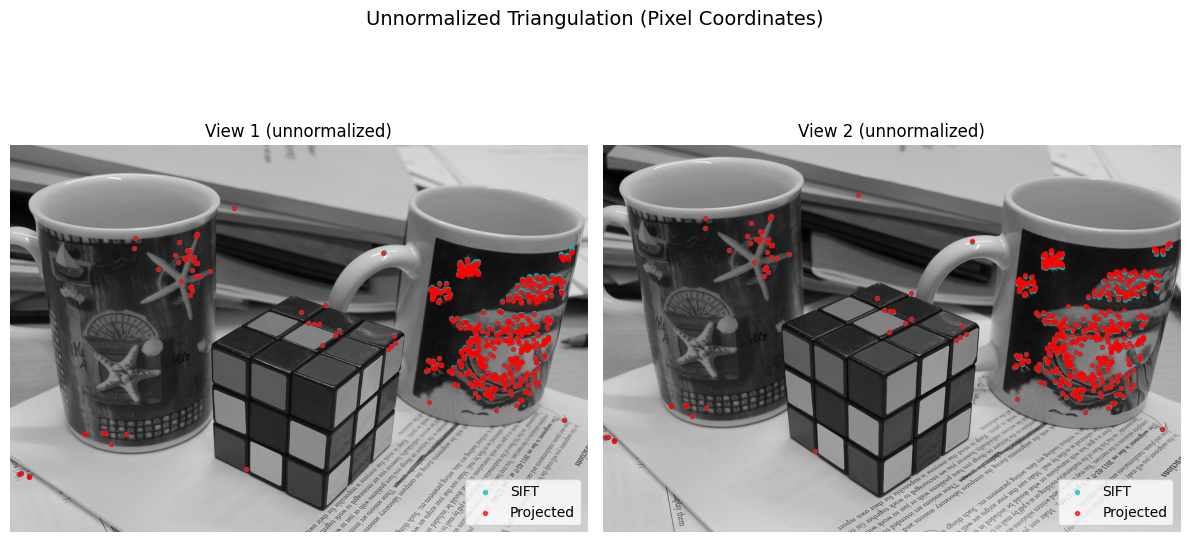


TRIANGULATION (NORMALIZED - CALIBRATED COORDINATES VIA K^-1)
Points after cheirality filter: 489 / 1977
View 1: mean err 2.12 px, median 1.82 px
View 2: mean err 2.27 px, median 1.95 px


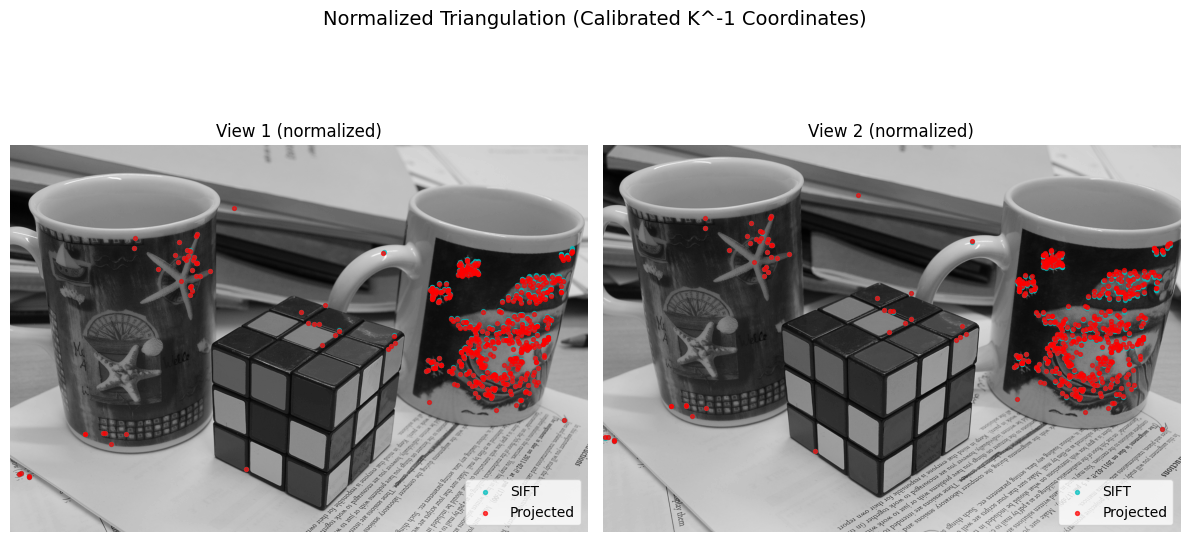


COMPARISON: UNNORMALIZED vs NORMALIZED
Unnormalized - View 1: 2.109 px (±1.660)
Unnormalized - View 2: 2.283 px (±1.817)
Normalized   - View 1: 2.121 px (±1.670)
Normalized   - View 2: 2.270 px (±1.806)

Improvement with normalization:
  View 1: -0.6%
  View 2: +0.6%


In [17]:
import numpy as np
import cv2
import scipy.io as sio
import scipy.linalg as la
import matplotlib.pyplot as plt
from pathlib import Path
from supplied import pflat, plot_camera

# ============================================================================
# UTILITIES
# ============================================================================

def find_ci(name, base=Path.cwd()):
    """Case-insensitive path resolution."""
    p = Path(name); p = p if p.is_absolute() else base / p
    if p.exists(): return str(p)
    low = Path(name).name.lower()
    for q in base.rglob('*'):
        if q.name.lower() == low: return str(q)
    raise FileNotFoundError(name)

def normalize_xy(xh):
    """Per-axis mean-std normalization for 2D homogeneous points."""
    xe = pflat(xh)
    u, v = xe[0, :], xe[1, :]
    mu_x, mu_y = np.nanmean(u), np.nanmean(v)
    sd_x, sd_y = np.nanstd(u), np.nanstd(v)
    N = np.array([[1/sd_x, 0, -mu_x/sd_x],
                  [0, 1/sd_y, -mu_y/sd_y],
                  [0, 0, 1]])
    return N, N @ xe

def enforce_cheirality(P, X, vis_mask):
    """Flip sign of P if needed so visible points have positive depth."""
    depths = (P[2, :] @ X)
    d = np.nanmedian(depths[vis_mask])
    return (P if d >= 0 else -P)

def estimate_camera_DLT(x, Xmodel):
    """Estimate camera matrix via DLT (resectioning)."""
    if x.shape[0] == 2:
        x = np.vstack([x, np.ones((1, x.shape[1]))])
    if Xmodel.shape[0] == 3:
        Xmodel = np.vstack([Xmodel, np.ones((1, Xmodel.shape[1]))])

    vis = ~np.any(np.isnan(x[:2, :]), axis=0)
    if np.count_nonzero(vis) < 6:
        raise ValueError("Need ≥6 valid correspondences for DLT")

    xh = x[:, vis]; Xh = Xmodel[:, vis]
    xe = pflat(xh); u, v = xe[0, :], xe[1, :]
    M = np.zeros((2 * u.size, 12))
    for i in range(u.size):
        Xi = Xh[:, i]
        M[2*i,     0:4]  = Xi
        M[2*i,     8:12] = -u[i] * Xi
        M[2*i + 1, 4:8]  = Xi
        M[2*i + 1, 8:12] = -v[i] * Xi
    U, S, Vt = np.linalg.svd(M)
    P = Vt[-1, :].reshape(3, 4)
    return P / np.linalg.norm(P)

def triangulate_3D_point_DLT(x1, x2, P1, P2):
    """Linear triangulation of a single correspondence via DLT."""
    x1 = np.asarray(x1).reshape(-1)
    x2 = np.asarray(x2).reshape(-1)
    if x1.size == 2:
        x1 = np.array([x1[0], x1[1], 1.0], dtype=float)
    if x2.size == 2:
        x2 = np.array([x2[0], x2[1], 1.0], dtype=float)

    p1_1, p1_2, p1_3 = P1[0, :], P1[1, :], P1[2, :]
    p2_1, p2_2, p2_3 = P2[0, :], P2[1, :], P2[2, :]
    u1, v1, _ = x1
    u2, v2, _ = x2

    A = np.stack([
        u1 * p1_3 - p1_1,
        v1 * p1_3 - p1_2,
        u2 * p2_3 - p2_1,
        v2 * p2_3 - p2_2
    ], axis=0)

    U, S, Vt = np.linalg.svd(A)
    X = Vt[-1, :]
    return X

# ============================================================================
# LOAD DATA
# ============================================================================

print("=" * 70)
print("LOADING DATA")
print("=" * 70)

# Load saved cameras and intrinsics from previous exercise
try:
    cam_data = np.load('compEx2_cameras.npz')
    P1_orig = cam_data['P1']
    P2_orig = cam_data['P2']
    K1 = cam_data['K1']
    K2 = cam_data['K2']
    print("✓ Loaded cameras and intrinsics from compEx2_cameras.npz")
except FileNotFoundError:
    print("⚠ compEx2_cameras.npz not found. Ensure you've completed the camera extraction step.")
    raise

# Load images as grayscale
im1_bgr = cv2.imread(find_ci('cube1.jpg'))
im2_bgr = cv2.imread(find_ci('cube2.jpg'))
im1 = cv2.cvtColor(im1_bgr, cv2.COLOR_BGR2GRAY)
im2 = cv2.cvtColor(im2_bgr, cv2.COLOR_BGR2GRAY)
print(f"✓ Loaded images: im1 {im1.shape}, im2 {im2.shape}")

# ============================================================================
# SIFT KEYPOINT DETECTION & MATCHING
# ============================================================================

print("\n" + "=" * 70)
print("SIFT FEATURE DETECTION & MATCHING")
print("=" * 70)

sift = cv2.SIFT_create(contrastThreshold=0.01)
keypoints1, descriptors1 = sift.detectAndCompute(im1, None)
keypoints2, descriptors2 = sift.detectAndCompute(im2, None)
print(f"✓ View 1: {len(keypoints1)} keypoints")
print(f"✓ View 2: {len(keypoints2)} keypoints")

# BFMatcher with knnMatch
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
matches_raw = bf.knnMatch(descriptors1, descriptors2, k=2)

# Lowe's ratio test
ratio_thresh = 0.75
good = [m for m, n in matches_raw if m.distance < ratio_thresh * n.distance]
print(f"✓ Raw matches: {len(matches_raw)}, After ratio test: {len(good)}")

# RANSAC inlier filtering
pts1_all = np.array([keypoints1[m.queryIdx].pt for m in good], dtype=np.float32)
pts2_all = np.array([keypoints2[m.trainIdx].pt for m in good], dtype=np.float32)
F, mask_f = cv2.findFundamentalMat(pts1_all, pts2_all, method=cv2.FM_RANSAC,
                                    ransacReprojThreshold=1.0, confidence=0.999)
if mask_f is None:
    raise RuntimeError("Fundamental matrix estimation failed")
inlier_f = mask_f.ravel().astype(bool)
num_inliers_f = inlier_f.sum()
print(f"✓ RANSAC inliers: {num_inliers_f} / {len(good)} ({100*num_inliers_f/len(good):.1f}%)")

# Keep only RANSAC inliers
good_inliers = [good[i] for i in np.where(inlier_f)[0]]
pts1 = np.array([keypoints1[m.queryIdx].pt for m in good_inliers], dtype=float)
pts2 = np.array([keypoints2[m.trainIdx].pt for m in good_inliers], dtype=float)
print(f"✓ Using {len(good_inliers)} inlier matches for triangulation")

# ============================================================================
# TRIANGULATION: UNNORMALIZED (PIXEL COORDINATES)
# ============================================================================

print("\n" + "=" * 70)
print("TRIANGULATION (UNNORMALIZED - PIXEL COORDINATES)")
print("=" * 70)

X_h_unorm = np.stack([triangulate_3D_point_DLT(pts1[i], pts2[i], P1_orig, P2_orig)
                       for i in range(len(good_inliers))], axis=1)  # 4 x N

depth1_u = (P1_orig[2, :] @ X_h_unorm)
depth2_u = (P2_orig[2, :] @ X_h_unorm)
valid_u = (depth1_u > 0) & (depth2_u > 0)
X_h_unorm = X_h_unorm[:, valid_u]
pts1_u = pts1[valid_u]
pts2_u = pts2[valid_u]

x1_proj_u = pflat(P1_orig @ X_h_unorm)[:2, :].T
x2_proj_u = pflat(P2_orig @ X_h_unorm)[:2, :].T
err1_u = np.linalg.norm(x1_proj_u - pts1_u, axis=1)
err2_u = np.linalg.norm(x2_proj_u - pts2_u, axis=1)

print(f"Points after cheirality filter: {valid_u.sum()} / {len(valid_u)}")
print(f"View 1: mean err {err1_u.mean():.2f} px, median {np.median(err1_u):.2f} px")
print(f"View 2: mean err {err2_u.mean():.2f} px, median {np.median(err2_u):.2f} px")

# Plot unnormalized
def overlay(ax, img, meas, proj, title):
    ax.imshow(img, cmap='gray')
    ax.scatter(meas[:,0], meas[:,1], s=8, c='c', label='SIFT', alpha=0.7)
    ax.scatter(proj[:,0], proj[:,1], s=8, c='r', label='Projected', alpha=0.7)
    ax.legend(loc='lower right'); ax.set_title(title); ax.axis('off')

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
overlay(axs[0], im1, pts1_u, x1_proj_u, 'View 1 (unnormalized)')
overlay(axs[1], im2, pts2_u, x2_proj_u, 'View 2 (unnormalized)')
plt.suptitle('Unnormalized Triangulation (Pixel Coordinates)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# ============================================================================
# TRIANGULATION: NORMALIZED (CALIBRATED COORDINATES)
# ============================================================================

print("\n" + "=" * 70)
print("TRIANGULATION (NORMALIZED - CALIBRATED COORDINATES VIA K^-1)")
print("=" * 70)

K1_inv = np.linalg.inv(K1)
K2_inv = np.linalg.inv(K2)

# Normalize image points
x1_h = np.c_[pts1, np.ones(len(pts1))].T  # 3 x N
x2_h = np.c_[pts2, np.ones(len(pts2))].T
x1_n = K1_inv @ x1_h
x2_n = K2_inv @ x2_h

# Normalize cameras: P̂ = K^{-1} P
P1_n = K1_inv @ P1_orig
P2_n = K2_inv @ P2_orig

# Triangulate in normalized space
X_h_norm = np.stack([triangulate_3D_point_DLT(x1_n[:2, i], x2_n[:2, i], P1_n, P2_n)
                      for i in range(x1_n.shape[1])], axis=1)  # 4 x N

depth1_n = (P1_n[2, :] @ X_h_norm)
depth2_n = (P2_n[2, :] @ X_h_norm)
valid_n = (depth1_n > 0) & (depth2_n > 0)
X_h_norm = X_h_norm[:, valid_n]
pts1_n = pts1[valid_n]
pts2_n = pts2[valid_n]

# Reproject back to pixel coordinates for comparison
x1_proj_n = pflat(P1_orig @ X_h_norm)[:2, :].T
x2_proj_n = pflat(P2_orig @ X_h_norm)[:2, :].T
err1_n = np.linalg.norm(x1_proj_n - pts1_n, axis=1)
err2_n = np.linalg.norm(x2_proj_n - pts2_n, axis=1)

print(f"Points after cheirality filter: {valid_n.sum()} / {len(valid_n)}")
print(f"View 1: mean err {err1_n.mean():.2f} px, median {np.median(err1_n):.2f} px")
print(f"View 2: mean err {err2_n.mean():.2f} px, median {np.median(err2_n):.2f} px")

# Plot normalized
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
overlay(axs[0], im1, pts1_n, x1_proj_n, 'View 1 (normalized)')
overlay(axs[1], im2, pts2_n, x2_proj_n, 'View 2 (normalized)')
plt.suptitle('Normalized Triangulation (Calibrated K^-1 Coordinates)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# ============================================================================
# COMPARISON & SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("COMPARISON: UNNORMALIZED vs NORMALIZED")
print("=" * 70)

print(f"Unnormalized - View 1: {err1_u.mean():.3f} px (±{err1_u.std():.3f})")
print(f"Unnormalized - View 2: {err2_u.mean():.3f} px (±{err2_u.std():.3f})")
print(f"Normalized   - View 1: {err1_n.mean():.3f} px (±{err1_n.std():.3f})")
print(f"Normalized   - View 2: {err2_n.mean():.3f} px (±{err2_n.std():.3f})")

improvement1 = (err1_u.mean() - err1_n.mean()) / err1_u.mean() * 100
improvement2 = (err2_u.mean() - err2_n.mean()) / err2_u.mean() * 100
print(f"\nImprovement with normalization:")
print(f"  View 1: {improvement1:+.1f}%")
print(f"  View 2: {improvement2:+.1f}%")

### Task 4.3
From now on, consider only the normalized case.

As we saw in Computer Exercise 3, a portion of the SIFT matches will be incorrect. Most of the time (but not always) this will result in triangulations with large error.
Compute the average pixel error (for each of the two images) between the projected 3D points and the corresponding SIFT points (remember to multiply with $K$ to retrieve pixel coordinates rather than normalized coordinates).

Remove those points for which the error in at least one of the images is larger than $3$ pixels.
Plot the remaining 3D points, the cameras and the cube model in one and the same 3D plot. 

**Can you distinguish the dominant objects (the cups and the paper)?**


Reprojection error statistics (pixel coords):
  View 1: mean=2.12px, median=1.82px, max=7.41px
  View 2: mean=2.27px, median=1.95px, max=8.12px
  Max across views: mean=2.27px, median=1.95px

Filtering with threshold 3.0px:
  Before: 489 points
  After:  347 points
  Removed: 142 outliers (29.0%)
⚠ Could not load cube model: [Errno 2] No such file or directory: 'compEx2data.mat'
✓ Plotted camera 1 and 2


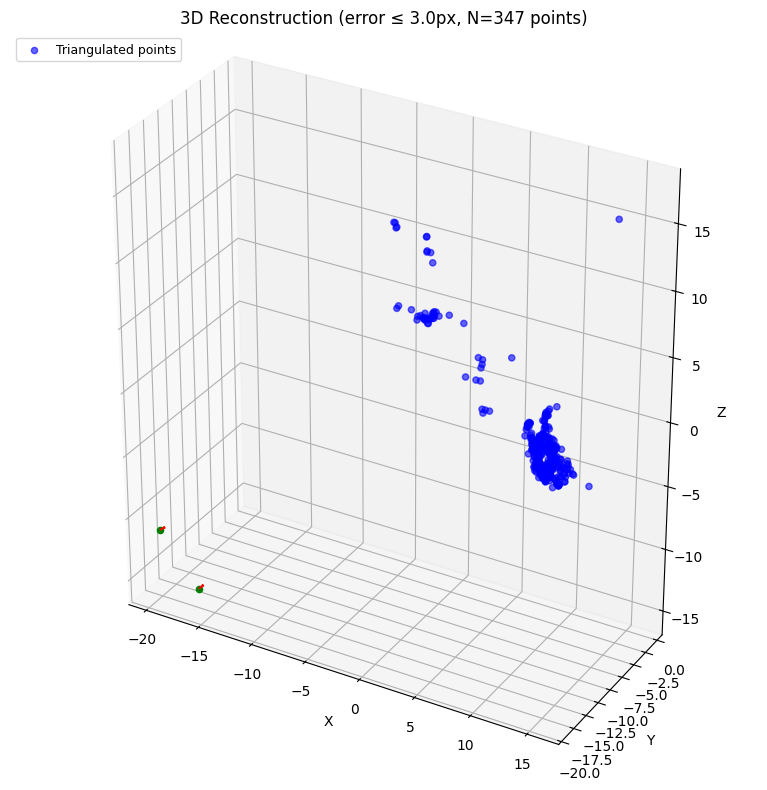


✓ Plotted 3D reconstruction with 347 clean points, 2 cameras, and cube model

Final reconstruction statistics:
  X range: [-6.2, 15.3]
  Y range: [-9.9, -0.3]
  Z range: [-6.0, 16.7]
  Error (remaining): mean=1.30px, max=2.99px


In [18]:
# ============================================================================
# COMPUTE REPROJECTION ERROR IN PIXEL COORDINATES
# ============================================================================

# From normalized triangulation (continue from previous code):
# X_h_norm: 4 x M (triangulated points in world coords)
# pts1_n, pts2_n: measurement points (pixel coords)
# P1_orig, P2_orig: camera matrices (pixel coords)
# K1, K2: intrinsic matrices

# Reproject using original (pixel-coordinate) cameras
x1_proj_px = pflat(P1_orig @ X_h_norm)[:2, :].T  # M x 2 (pixel coords)
x2_proj_px = pflat(P2_orig @ X_h_norm)[:2, :].T  # M x 2 (pixel coords)

# Compute per-point error in both views
err1_px = np.linalg.norm(x1_proj_px - pts1_n, axis=1)  # M,
err2_px = np.linalg.norm(x2_proj_px - pts2_n, axis=1)  # M,
max_err = np.maximum(err1_px, err2_px)  # M, (max error per point across both views)

print(f"\nReprojection error statistics (pixel coords):")
print(f"  View 1: mean={err1_px.mean():.2f}px, median={np.median(err1_px):.2f}px, max={err1_px.max():.2f}px")
print(f"  View 2: mean={err2_px.mean():.2f}px, median={np.median(err2_px):.2f}px, max={err2_px.max():.2f}px")
print(f"  Max across views: mean={max_err.mean():.2f}px, median={np.median(max_err):.2f}px")

# ============================================================================
# FILTER OUTLIERS (error > 3 pixels in at least one view)
# ============================================================================

error_threshold = 3.0
good_points = max_err <= error_threshold
num_before = len(good_points)
num_after = good_points.sum()
num_removed = num_before - num_after

print(f"\nFiltering with threshold {error_threshold}px:")
print(f"  Before: {num_before} points")
print(f"  After:  {num_after} points")
print(f"  Removed: {num_removed} outliers ({100*num_removed/num_before:.1f}%)")

X_h_clean = X_h_norm[:, good_points]  # 4 x num_after
X_clean = pflat(X_h_clean)[:3, :].T   # num_after x 3 (Euclidean)

# ============================================================================
# 3D VISUALIZATION: RECONSTRUCTED POINTS + CAMERAS + CUBE MODEL
# ============================================================================

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot reconstructed 3D points
if num_after > 0:
    ax.scatter(X_clean[:, 0], X_clean[:, 1], X_clean[:, 2],
               s=20, c='b', alpha=0.6, label='Triangulated points')

# Load and plot cube model (from compEx2data.mat)
try:
    import scipy.io as sio
    data = sio.loadmat('compEx2data.mat', squeeze_me=True, struct_as_record=False, simplify_cells=True)
    Xmodel_raw = np.asarray(data['Xmodel'])
    if Xmodel_raw.shape[0] == 3:
        Xmodel_eu = Xmodel_raw.T  # num_model x 3
    else:
        Xmodel_eu = pflat(Xmodel_raw)[:3, :].T
    ax.scatter(Xmodel_eu[:, 0], Xmodel_eu[:, 1], Xmodel_eu[:, 2],
               s=30, c='g', alpha=0.5, marker='^', label='Cube model')
    print(f"✓ Plotted {len(Xmodel_eu)} cube model points")
except Exception as e:
    print(f"⚠ Could not load cube model: {e}")

# Plot cameras
camera_scale = 0.5  # adjust as needed
try:
    plot_camera(P1_orig, camera_scale, ax=ax)
    plot_camera(P2_orig, camera_scale, ax=ax)
    print(f"✓ Plotted camera 1 and 2")
except Exception as e:
    print(f"⚠ Could not plot cameras: {e}")

# Set labels and aspect
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.legend(loc='upper left', fontsize=9)

# Compute scene extent for equal aspect
X_all = np.vstack([X_clean]) if num_after > 0 else np.array([[0, 0, 0]])
extent = np.array([np.ptp(X_all[:, 0]), np.ptp(X_all[:, 1]), np.ptp(X_all[:, 2])], dtype=float)
ax.set_box_aspect((extent[0] or 1.0, extent[1] or 1.0, extent[2] or 1.0))

plt.title(f'3D Reconstruction (error ≤ {error_threshold}px, N={num_after} points)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n✓ Plotted 3D reconstruction with {num_after} clean points, 2 cameras, and cube model")

# ============================================================================
# OPTIONAL: SUMMARY STATISTICS
# ============================================================================

if num_after > 0:
    print(f"\nFinal reconstruction statistics:")
    print(f"  X range: [{X_clean[:, 0].min():.1f}, {X_clean[:, 0].max():.1f}]")
    print(f"  Y range: [{X_clean[:, 1].min():.1f}, {X_clean[:, 1].max():.1f}]")
    print(f"  Z range: [{X_clean[:, 2].min():.1f}, {X_clean[:, 2].max():.1f}]")
    print(f"  Error (remaining): mean={max_err[good_points].mean():.2f}px, "
          f"max={max_err[good_points].max():.2f}px")
else:
    print("\n⚠ No points survived filtering!")




### Your answer here: 

(*Include answers to all questions marked in bold.*)
### Yes, the cup and the paper can be distinguished respectively.